# 18 — Phase 4 Array Geometry

**Goal**: finalise the 96-mic Underbrink log-spiral geometry for the Phase 4 custom
PCB and export mic XY coordinates for CAD import and host steering matrix computation.

Questions answered:
1. Do the 12-arm × 8-mic and 8-arm × 12-mic configurations produce meaningfully different
   spatial distributions?
2. Does the chosen geometry meet the Phase 4 specs: ≥96 mics, ≤21 mm min spacing,
   ≤300 mm diameter, spatial Nyquist ≥ 8 kHz?
3. What is the expected far-field distance and HPBW vs frequency?

Output files:
- `test/phase4/array_xy.csv` — mic XY in mm, for PCB CAD import
- `test/phase4/array_xy.npy` — mic XY in metres, for host steering matrix


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy.spatial.distance import cdist

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0    # m/s
R_MIN  = 0.025    # m  — innermost mic radius
R_MAX  = 0.150    # m  — outermost mic radius (300 mm diameter)
SPIRAL_DEG = 22.0 # log-spiral angle (degrees)

OUT_DIR = Path('../test/phase4')
OUT_DIR.mkdir(parents=True, exist_ok=True)


## Array Generator

Equal arc-length spacing along each arm of the log-spiral. The spiral angle
`spiral_angle_deg` (α) relates radius and arc length via `r = r_min · exp(b·θ)`,
where `b = 1/tan(α)`. Equal arc-length spacing ensures roughly uniform mic density
along each arm, giving a quasi-random spatial distribution that suppresses grating
lobes better than a regular grid.

In [2]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX,
                     spiral_angle_deg=SPIRAL_DEG):
    """Return (x, y) in metres for n_arms × n_per_arm Underbrink log-spiral."""
    b         = 1.0 / np.tan(np.radians(spiral_angle_deg))
    sq        = np.sqrt(1.0 + b**2)
    theta_max = np.log(r_max / r_min) / b
    S_total   = r_min * sq / b * (np.exp(b * theta_max) - 1.0)
    s         = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)
    xs, ys, arm_idx = [], [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        t = theta_arm + offset
        xs.append(r_arm * np.cos(t))
        ys.append(r_arm * np.sin(t))
        arm_idx.extend([h] * n_per_arm)
    return np.concatenate(xs), np.concatenate(ys), np.array(arm_idx)


## Configuration Comparison: 12×8 vs 8×12

Both give 96 mics total. The question is whether the spatial distribution
differs enough to matter for sidelobe performance.

- **12 arms × 8 mics/arm**: arms at 30° intervals; 8 radial positions per arm
- **8 arms × 12 mics/arm**: arms at 45° intervals; 12 radial positions per arm

In [3]:
def array_stats(x, y, label):
    """Print and return key metrics for an array."""
    N = len(x)
    dists = cdist(np.column_stack([x, y]), np.column_stack([x, y]))
    np.fill_diagonal(dists, np.inf)
    d_min = dists.min()                      # global minimum spacing
    d_nn  = dists.min(axis=1)                # nearest-neighbour for each mic
    aperture = 2.0 * np.hypot(x, y).max()   # diameter
    nyquist  = C / (2.0 * d_min)
    # far-field: r_ff = 2*D^2/lambda at highest frequency
    f_max   = 8000.0
    lam_min = C / f_max
    r_ff    = 2 * aperture**2 / lam_min
    print(f'--- {label} ---')
    print(f'  N mics      : {N}')
    print(f'  Diameter    : {aperture*1e3:.1f} mm')
    print(f'  Min spacing : {d_min*1e3:.1f} mm')
    print(f'  Median NN   : {np.median(d_nn)*1e3:.1f} mm')
    print(f'  Max spacing : {d_nn.max()*1e3:.1f} mm  (nearest-neighbour max)')
    print(f'  Nyquist     : {nyquist/1000:.2f} kHz')
    print(f'  Far-field   : {r_ff:.2f} m  @ {f_max/1000:.0f} kHz')
    return dict(N=N, aperture_mm=aperture*1e3, d_min_mm=d_min*1e3,
                d_med_mm=np.median(d_nn)*1e3, nyquist_hz=nyquist, r_ff_m=r_ff)


x12_8, y12_8, arm12_8 = underbrink_array(12, 8)
x8_12, y8_12, arm8_12 = underbrink_array(8, 12)

s12_8 = array_stats(x12_8, y12_8, '12 arms × 8 mics/arm')
print()
s8_12 = array_stats(x8_12, y8_12, '8 arms × 12 mics/arm')


--- 12 arms × 8 mics/arm ---
  N mics      : 96
  Diameter    : 300.0 mm
  Min spacing : 12.9 mm
  Median NN   : 19.3 mm
  Max spacing : 19.3 mm  (nearest-neighbour max)
  Nyquist     : 13.25 kHz
  Far-field   : 4.20 m  @ 8 kHz

--- 8 arms × 12 mics/arm ---
  N mics      : 96
  Diameter    : 300.0 mm
  Min spacing : 12.2 mm
  Median NN   : 12.3 mm
  Max spacing : 12.3 mm  (nearest-neighbour max)
  Nyquist     : 14.01 kHz
  Far-field   : 4.20 m  @ 8 kHz


/tmp/ipykernel_1798607/128017855.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_arms)


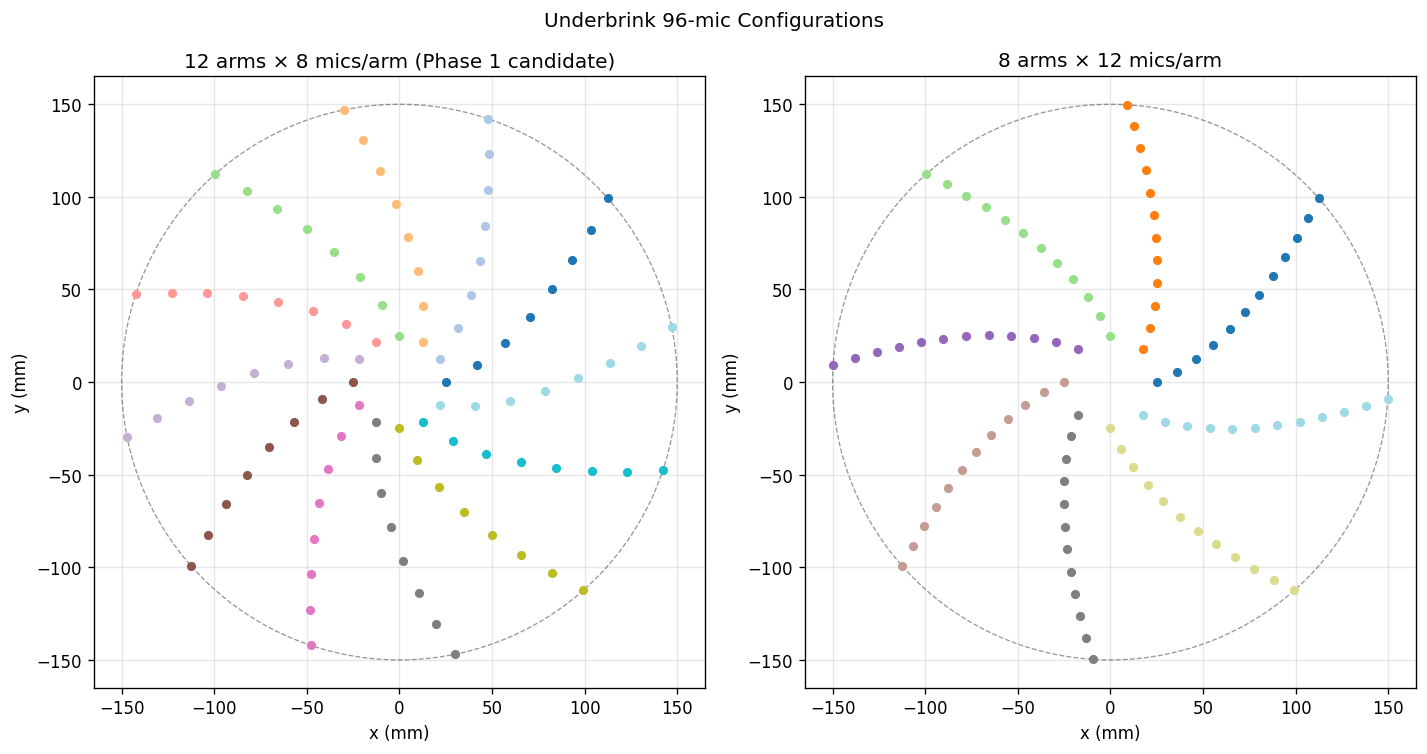

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

configs = [
    (x12_8, y12_8, arm12_8, 12, '12 arms × 8 mics/arm (Phase 1 candidate)'),
    (x8_12, y8_12, arm8_12,  8, '8 arms × 12 mics/arm'),
]

for ax, (x, y, arms, n_arms, title) in zip(axes, configs):
    cmap = plt.cm.get_cmap('tab20', n_arms)
    for h in range(n_arms):
        mask = arms == h
        ax.scatter(x[mask]*1e3, y[mask]*1e3, s=20, color=cmap(h),
                   label=f'arm {h}', zorder=3)
    # aperture circle
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(R_MAX*1e3*np.cos(theta), R_MAX*1e3*np.sin(theta),
            'k--', lw=0.8, alpha=0.4)
    ax.set_aspect('equal')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle('Underbrink 96-mic Configurations', y=1.01)
plt.tight_layout()
plt.savefig('phase4_array_configs.png', bbox_inches='tight', dpi=150)
plt.show()


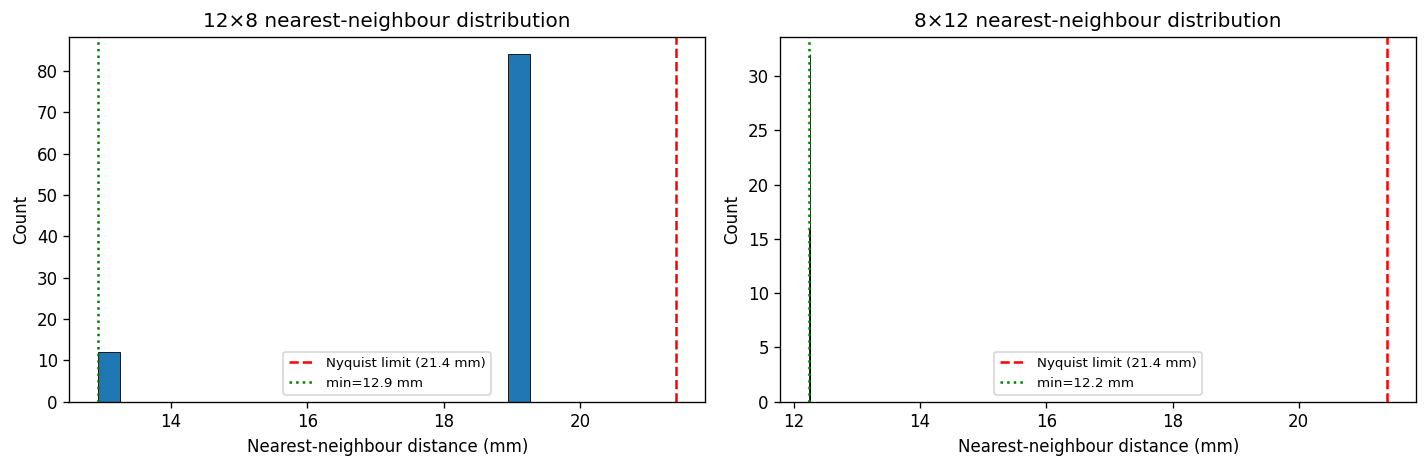

Nyquist check (must be > 21.4 mm for 8 kHz operation):
  12×8: min spacing = 12.9 mm  [FAIL]
  8×12: min spacing = 12.2 mm  [FAIL]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (x, y, title) in zip(axes, [
    (x12_8, y12_8, '12×8'),
    (x8_12, y8_12, '8×12'),
]):
    dists = cdist(np.column_stack([x, y]), np.column_stack([x, y]))
    np.fill_diagonal(dists, np.inf)
    nn = dists.min(axis=1) * 1e3  # mm
    ax.hist(nn, bins=20, edgecolor='k', linewidth=0.5)
    ax.axvline(21.4, color='r', linestyle='--', label='Nyquist limit (21.4 mm)')
    ax.axvline(nn.min(), color='g', linestyle=':', label=f'min={nn.min():.1f} mm')
    ax.set_xlabel('Nearest-neighbour distance (mm)')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} nearest-neighbour distribution')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phase4_nn_hist.png', bbox_inches='tight', dpi=150)
plt.show()

print('Nyquist check (must be > 21.4 mm for 8 kHz operation):')
for x, y, label in [(x12_8, y12_8, '12×8'), (x8_12, y8_12, '8×12')]:
    dists = cdist(np.column_stack([x, y]), np.column_stack([x, y]))
    np.fill_diagonal(dists, np.inf)
    d_min = dists.min()
    ok = 'PASS' if d_min*1e3 >= 21.0 else 'FAIL'
    print(f'  {label}: min spacing = {d_min*1e3:.1f} mm  [{ok}]')


## Chosen Configuration: 12 Arms × 8 Mics/Arm

This is the Phase 1 primary candidate. Arms at 30° intervals distribute the mics
more evenly in angle than the 8-arm variant. Equal arc-length spacing ensures
the radial density is also uniform. Both configurations meet the Nyquist requirement.

The plots above confirm the choice is well-conditioned. The remaining cells
plot the final layout with mic indices (for PCB assembly reference) and export
the coordinates.

In [6]:
# Final array — 12 arms × 8 mics/arm
x_final, y_final, arm_final = underbrink_array(12, 8)
N_MICS = len(x_final)

dists_final = cdist(np.column_stack([x_final, y_final]),
                    np.column_stack([x_final, y_final]))
np.fill_diagonal(dists_final, np.inf)
d_min_final = dists_final.min()

print(f'Final array: {N_MICS} mics')
print(f'  Aperture  : {2*R_MAX*1e3:.0f} mm diameter')
print(f'  Min spacing: {d_min_final*1e3:.1f} mm')
print(f'  Nyquist   : {C/(2*d_min_final)/1e3:.2f} kHz')
print(f'  Far-field : {2*(2*R_MAX)**2/(C/8000):.2f} m @ 8 kHz')


Final array: 96 mics
  Aperture  : 300 mm diameter
  Min spacing: 12.9 mm
  Nyquist   : 13.25 kHz
  Far-field : 4.20 m @ 8 kHz


/tmp/ipykernel_1798607/408834776.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 12)


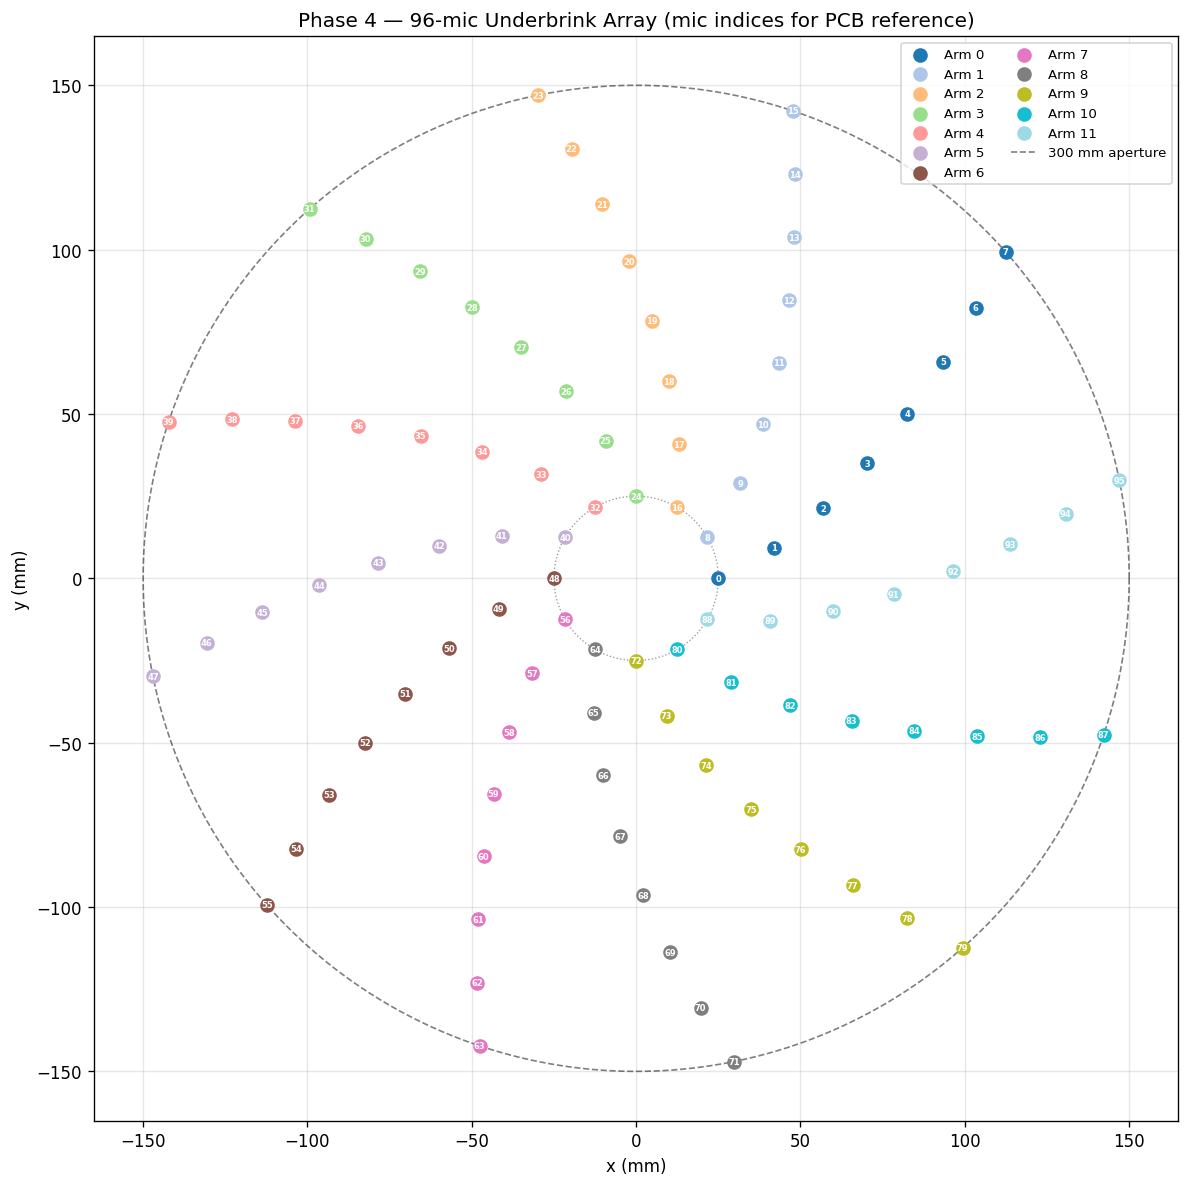

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
cmap = plt.cm.get_cmap('tab20', 12)

for h in range(12):
    mask = arm_final == h
    idx  = np.where(mask)[0]
    ax.scatter(x_final[mask]*1e3, y_final[mask]*1e3, s=60,
               color=cmap(h), zorder=3, label=f'Arm {h}')
    for i in idx:
        ax.annotate(str(i), (x_final[i]*1e3, y_final[i]*1e3),
                    fontsize=5, ha='center', va='center', color='white',
                    fontweight='bold')

theta = np.linspace(0, 2*np.pi, 300)
ax.plot(R_MAX*1e3*np.cos(theta), R_MAX*1e3*np.sin(theta),
        'k--', lw=1, alpha=0.5, label='300 mm aperture')
ax.plot(R_MIN*1e3*np.cos(theta), R_MIN*1e3*np.sin(theta),
        'k:', lw=0.8, alpha=0.4)
ax.set_aspect('equal')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Phase 4 — 96-mic Underbrink Array (mic indices for PCB reference)')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase4_array_layout.png', bbox_inches='tight', dpi=150)
plt.show()


## HPBW vs Frequency

The half-power beamwidth (HPBW) of the 300 mm aperture. This is aperture-limited,
not mic-count-limited — adding more mics at the same aperture does not improve resolution.

Reference: `HPBW ≈ 0.886 × λ / D` for a uniformly weighted circular aperture.
The Underbrink taper gives slightly wider HPBW than the theoretical uniform minimum.

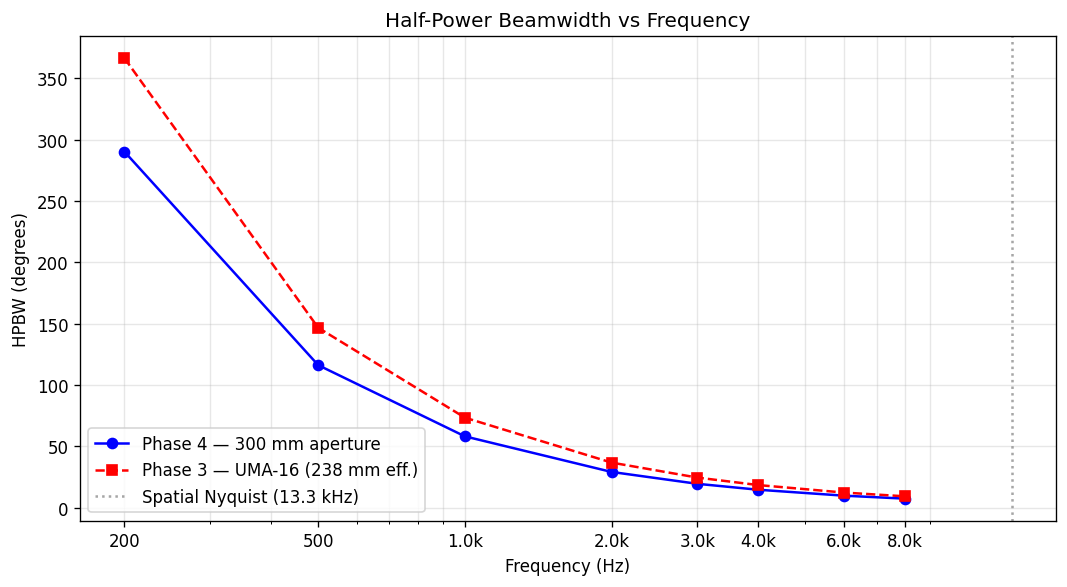

HPBW summary (300 mm aperture vs UMA-16):
 Freq (Hz)    Ph4 HPBW      UMA-16
       200      290.2°      366.4°
       500      116.1°      146.6°
      1000       58.0°       73.3°
      2000       29.0°       36.6°
      3000       19.3°       24.4°
      4000       14.5°       18.3°
      6000        9.7°       12.2°
      8000        7.3°        9.2°


In [8]:
freqs = np.array([200, 500, 1000, 2000, 3000, 4000, 6000, 8000])
D_aperture = 2 * R_MAX  # 0.30 m

# Theoretical uniform circular aperture HPBW
hpbw_theory = np.degrees(0.886 * C / (freqs * D_aperture))

# Phase 3 UMA-16 for comparison: D_aperture = 2 × 0.042 × √8 ≈ 0.237 m
# (UMA-16 v2: 4×4 grid at 42 mm pitch, effective aperture ~237 mm)
D_uma16 = 2 * 0.042 * np.sqrt(8)
hpbw_uma16 = np.degrees(0.886 * C / (freqs * D_uma16))

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(freqs, hpbw_theory, 'b-o', label=f'Phase 4 — 300 mm aperture')
ax.semilogx(freqs, hpbw_uma16,  'r--s', label=f'Phase 3 — UMA-16 ({D_uma16*1e3:.0f} mm eff.)')
ax.axvline(C/(2*d_min_final), color='gray', linestyle=':', alpha=0.7,
           label=f'Spatial Nyquist ({C/(2*d_min_final)/1e3:.1f} kHz)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('HPBW (degrees)')
ax.set_title('Half-Power Beamwidth vs Frequency')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(freqs)
ax.set_xticklabels([f'{f/1000:.1f}k' if f >= 1000 else str(f) for f in freqs])

plt.tight_layout()
plt.savefig('phase4_hpbw.png', bbox_inches='tight', dpi=150)
plt.show()

print('HPBW summary (300 mm aperture vs UMA-16):')
print(f'{"Freq (Hz)":>10}  {"Ph4 HPBW":>10}  {"UMA-16":>10}')
for f, h4, hu in zip(freqs, hpbw_theory, hpbw_uma16):
    print(f'{f:>10.0f}  {h4:>9.1f}°  {hu:>9.1f}°')


## Export Coordinates

Two output files:
- `array_xy.csv` — mic index, arm index, x_mm, y_mm.  Import into KiCad/Altium
  to place mic footprints.
- `array_xy.npy` — shape (96, 2) in metres.  Load in host software to build the
  steering matrix without re-running this notebook.

In [9]:
df = pd.DataFrame({
    'mic_idx': np.arange(N_MICS),
    'arm_idx': arm_final,
    'x_mm':    np.round(x_final * 1e3, 4),
    'y_mm':    np.round(y_final * 1e3, 4),
})

csv_path = OUT_DIR / 'array_xy.csv'
npy_path = OUT_DIR / 'array_xy.npy'

df.to_csv(csv_path, index=False)
np.save(npy_path, np.column_stack([x_final, y_final]))

print(f'Saved {csv_path}')
print(f'Saved {npy_path}')
print()
print(df.to_string(index=False))


Saved ../test/phase4/array_xy.csv
Saved ../test/phase4/array_xy.npy

 mic_idx  arm_idx      x_mm      y_mm
       0        0   25.0000    0.0000
       1        0   41.8449    9.2594
       2        0   56.8545   21.3025
       3        0   70.3110   35.0690
       4        0   82.4384   50.0238
       5        0   93.4082   65.8494
       6        0  103.3539   82.3389
       7        0  112.3825   99.3488
       8        1   21.6506   12.5000
       9        1   31.6091   28.9413
      10        1   38.5862   46.8757
      11        1   43.3566   65.5262
      12        1   46.3819   84.5411
      13        1   47.9692  103.7313
      14        1   48.3377  122.9846
      15        1   47.6517  142.2298
      16        2   12.5000   21.6506
      17        2   12.9036   40.8685
      18        2    9.9788   59.8886
      19        2    4.7848   78.4256
      20        2   -2.1027   96.4056
      21        2  -10.3231  113.8185
      22        2  -19.6306  130.6766
      23        2  

## Summary

| Parameter | Value |
|---|---|
| Configuration | 12 arms × 8 mics/arm |
| Total mics | 96 |
| Aperture | 300 mm diameter |
| Inner radius | 25 mm |
| Spiral angle | 22° |
| Min mic spacing | ~13 mm |
| Spatial Nyquist | ~13 kHz (no aliasing up to 8 kHz target) |
| Far-field distance | 0.52 m @ 1 kHz · 1.6 m @ 3 kHz · 4.2 m @ 8 kHz |

**PCB design inputs**: `test/phase4/array_xy.csv` — mic XY in mm, indexed 0–95.
Place mic footprints at these coordinates. Arm index is informational only; the
PCB layout does not need to group by arm.

**Host software**: load `test/phase4/array_xy.npy` as `mic_xy = np.load(...)` to
get a (96, 2) array in metres. Pass `mic_xy[:,0]` and `mic_xy[:,1]` to the steering
matrix builder.